<a href="https://colab.research.google.com/github/sanchezromeroaday-web/Computacional/blob/main/Obligatorio4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Viaje a la Luna: El Problema Restringido de los Tres Cuerpos

## Introducción
En este notebook analizamos el envío de una nave espacial a la Luna modelándolo como un problema restringido de tres cuerpos. Para simplificar el sistema, asumimos que la Tierra permanece inmóvil y la Luna describe una órbita circular a su alrededor con una velocidad angular constante $\omega$. La masa de la nave ($m$) es despreciable frente a las masas de la Tierra ($M_T$) y la Luna ($M_L$), por lo que no perturba sus órbitas.

El sistema interactúa únicamente mediante fuerzas gravitatorias. A partir de las integraciones numéricas realizadas en C++ mediante el algoritmo de Runge-Kutta de cuarto orden (RK4), utilizamos Python para visualizar las trayectorias resultantes y estudiar las constantes del movimiento.

## 1. Visualización de Trayectorias

El objetivo principal es identificar condiciones iniciales bajo las cuales la trayectoria del cohete se ve visiblemente alterada por el campo gravitatorio lunar. Dependiendo de la velocidad de lanzamiento y el ángulo, la nave puede impactar en la Luna, quedar atrapada en una órbita, regresar a la Tierra o perderse en el espacio.

A continuación, visualizamos los resultados obtenidos tras ejecutar la simulación para distintos parámetros.

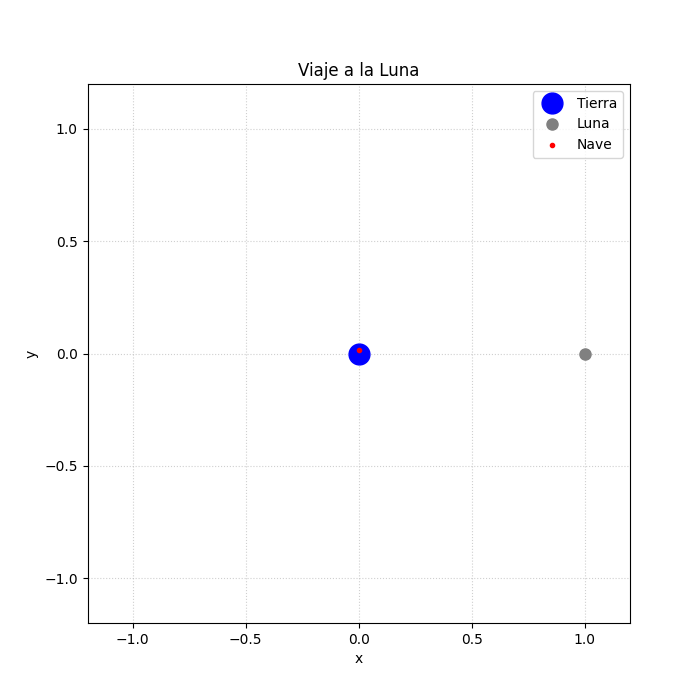

In [112]:
from IPython.display import Image
Image(filename="cohete.gif", width=600)

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Cargar los datos
data = np.loadtxt("data.dat")

moon_x = data[:, 0]
moon_y = data[:, 1]
rocket_x = data[:, 2]
rocket_y = data[:, 3]

IT = len(data) # Total de iteraciones

fig, ax = plt.subplots(figsize=(7, 7))

# Arrays vacíos para la estela del cohete
xldata, yldata = [], []

# Inicialización de los elementos gráficos (nota la coma después de las variables)
tierra, = plt.plot(0, 0, linestyle='None', color="Blue", marker='o', markersize=15, label="Tierra")
luna, = plt.plot([], [], linestyle='None', color="Grey", marker='o', markersize=8, label="Luna")
cohete, = plt.plot([], [], linestyle='None', color="Red", marker='.', markersize=6, label="Nave")
lcohete, = plt.plot([], [], linestyle='-', color="Red", alpha=0.5, linewidth=1.5)

def init():
    ax.set_title("Viaje a la Luna")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.legend(loc="upper right")
    ax.grid(True, linestyle=':', alpha=0.6)
    return luna, cohete, lcohete

def update(i):
    # Controlamos el tamaño de la estela (trail) del cohete (ej. últimos 150 puntos)
    if len(xldata) > 150:
        xldata.pop(0)
        yldata.pop(0)

    xldata.append(rocket_x[i])
    yldata.append(rocket_y[i])

    lcohete.set_data(xldata, yldata)

    # En versiones recientes de matplotlib, set_data espera listas o arrays
    luna.set_data([moon_x[i]], [moon_y[i]])
    cohete.set_data([rocket_x[i]], [rocket_y[i]])

    return luna, cohete, lcohete

# Animamos tomando 1 frame cada 1000 iteraciones para no sobrecargar el GIF
paso_frames = 5000
frames_totales = range(0, IT, paso_frames)

anim = animation.FuncAnimation(fig, update, frames=frames_totales,
                               init_func=init, blit=True)

# Guardar como GIF
print("Generando GIF, esto puede tardar un momento...")
anim.save("cohete.gif", writer=animation.PillowWriter(fps=30))
print("GIF guardado con éxito.")

plt.close()

Generando GIF, esto puede tardar un momento...
GIF guardado con éxito.


## 2. Demostración de la Conservación de $H'$

Se nos pide demostrar analíticamente que la magnitud $H' = H - \omega p_\phi$ es una constante del movimiento, es decir, que $\frac{dH'}{dt} = 0$.

El hamiltoniano del sistema viene dado por:
$$H = \frac{p_r^2}{2m} + \frac{p_\phi^2}{2mr^2} - G\frac{mM_T}{r} - G\frac{mM_L}{r_L(r,\phi,t)}$$

La dependencia temporal explícita en $H$ entra únicamente a través de la distancia a la Luna, $r_L(r,\phi,t)$, que depende del término $\cos(\phi - \omega t)$.

La derivada total del hamiltoniano respecto al tiempo es igual a su derivada parcial explícita:
$$\frac{dH}{dt} = \frac{\partial H}{\partial t}$$

Como la dependencia de las variables angulares y temporales en $H$ siempre aparece en la forma combinada $(\phi - \omega t)$, podemos aplicar la regla de la cadena:
$$\frac{\partial H}{\partial t} = \frac{\partial H}{\partial (\phi - \omega t)} \frac{\partial (\phi - \omega t)}{\partial t} = -\omega \frac{\partial H}{\partial \phi}$$

Por otro lado, a partir de las ecuaciones canónicas de Hamilton, sabemos que la evolución del momento conjugado $p_\phi$ es:
$$\dot{p}_\phi = -\frac{\partial H}{\partial \phi}$$

Sustituyendo esto en la ecuación anterior, obtenemos:
$$\frac{dH}{dt} = \omega \dot{p}_\phi$$

Integrando respecto al tiempo, resulta:
$$\frac{d}{dt}(H - \omega p_\phi) = 0$$

Por lo tanto, la magnitud $H' = H - \omega p_\phi$, conocida en mecánica celeste como la integral de Jacobi, se conserva exactamente en el modelo teórico.

## 3. Conservación de $H'$ en la Simulación Numérica

Aunque $H'$ se conserva teóricamente, al calcular su valor a lo largo del tiempo utilizando los datos generados por nuestro programa en C++, observaremos si esta conservación se mantiene exactamente.

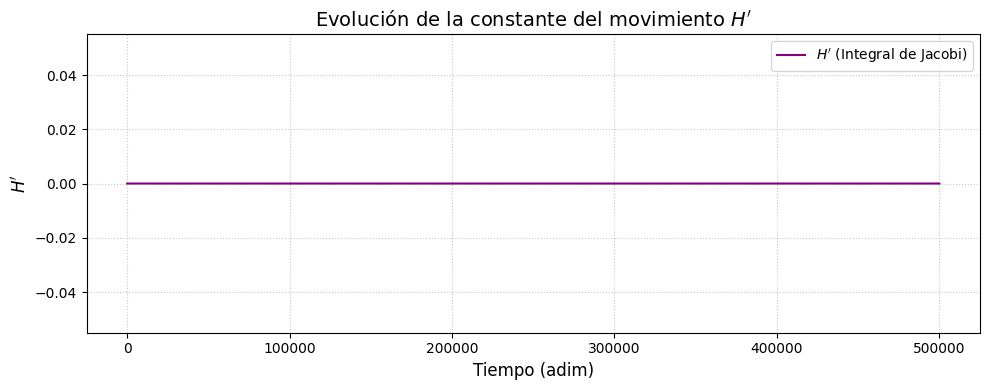

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Cargar los datos
# Para esta gráfica solo necesitamos la columna 4 (Tiempo) y la 5 (H_prima)
data = np.loadtxt("data.dat")

t = data[:, 4]
H_prima = data[:, 5]

# ==========================================
# GRÁFICA: CONSERVACIÓN DE H'
# ==========================================
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(t, H_prima, color='purple', linewidth=1.5, label=r"$H'$ (Integral de Jacobi)")

ax.set_title("Evolución de la constante del movimiento $H'$", fontsize=14)
ax.set_xlabel("Tiempo (adim)", fontsize=12)
ax.set_ylabel(r"$H'$", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend()

# Usar notación científica en el eje Y si las variaciones son muy pequeñas
ax.ticklabel_format(useOffset=False, style='plain')

fig.tight_layout()
fig.savefig("constante_H.png", dpi=300)

plt.show()

# Anexo

En este partado incluyo el código en C++ que realiza todos los cálculos necesarios


In [109]:
%%writefile cohete.cpp
#include <iostream>
#include <fstream>
#include <cmath>
#include <vector>
#include <array>
#include <iomanip>

using namespace std;

//? CONSTANTES UNIVERSALES Y FÍSICAS
constexpr double PI = 3.14159265358979323846;
constexpr double G = 6.674e-11;

constexpr double MT = 5.9736e24;   // Masa Tierra (Kg)
constexpr double ML = 0.07349e24;  // Masa Luna (Kg)
constexpr double RT = 6.378160e6;  // Radio Tierra (m)
constexpr double RL = 1.7374e6;    // Radio Luna (m)

constexpr double DTL = 3.844e8;    // Radio órbita Tierra-Luna (m)
constexpr double OMEGA = 2.6617e-6; // Periodo órbita Luna (s)

constexpr double DELTA = 7.01474e-12; // Parámetro Delta
constexpr double MU = 0.0123025;      // Parámetro Mu

//? PARÁMETROS DE LA SIMULACIÓN
constexpr int ITER = 1500000; // Iteraciones a realizar
constexpr double H_STEP = 1.0; // Paso de integración h

//? ECUACIONES DIFERENCIALES
// n = 0 (pr), n = 1 (pphi/r^2), n = 2 (dot_pr), n = 3 (dot_pphi)
double f(int n, const array<double, 4>& y, double t) {
    double r = y[0];
    double phi = y[1];
    double pr = y[2];
    double pphi = y[3];

    double rprima = sqrt(1.0 + r*r - 2.0*r*cos(phi - OMEGA*t));

    if (n == 0) return pr;
    if (n == 1) return pphi / (r*r);
    if (n == 2) return (pphi*pphi) / (r*r*r) - DELTA * (1.0 / (r*r) + (MU / (rprima*rprima*rprima)) * (r - cos(phi - OMEGA*t)));
    if (n == 3) return - (DELTA * MU * r / (rprima*rprima*rprima)) * sin(phi - OMEGA*t);

    return 0.0;
}

//? FUNCIÓN PARA CALCULAR LA CONSTANTE DEL MOVIMIENTO H'
double calcular_H_prima(const array<double, 4>& y, double t) {
    double r = y[0];
    double phi = y[1];
    double pr = y[2];
    double pphi = y[3];

    double rprima = sqrt(1.0 + r*r - 2.0*r*cos(phi - OMEGA*t));

    // Hamiltoniano H
    double H = 0.5 * (pr*pr + (pphi*pphi)/(r*r)) - (DELTA / r) - (DELTA * MU / rprima);

    // H' = H - omega * pphi
    return H - OMEGA * pphi;
}

int main() {
    //? VALORES INICIALES
 double theta = PI / 2.5;
double v = 11080.0 / DTL; // Velocidad inicial en m/s escalada por DTL
    // Vector y(t) = {Radio(0), ángulo(1), momento radial(2), momento angular(3)}
    array<double, 4> y = {
        RT / DTL,
        PI / 2.0,
        v * cos(theta - PI / 2.0),
        (RT / DTL) * v * sin(theta - PI / 2.0)
    };

    // Arrays para los pasos de Runge-Kutta
    array<double, 4> k1, k2, k3, k4;
    array<double, 4> y_temp;

    //? ABRIMOS FICHERO DE SALIDA USANDO fstream
    ofstream out("data.dat");
    if (!out.is_open()) {
        cerr << "Error al abrir el archivo data.dat" << endl;
        return 1;
    }

    double t = 0.0;
    bool paso = false;

    // Guardamos el estado inicial (X_luna, Y_luna, X_cohete, Y_cohete, tiempo, H_prima)
    out << fixed << setprecision(8);
    out << 1.0 << "\t" << 0.0 << "\t"
        << y[0]*cos(y[1]) << "\t" << y[0]*sin(y[1]) << "\t"
        << t << "\t" << calcular_H_prima(y, t) << "\n";

    //! BUCLE PRINCIPAL (RK4)
    for (int k = 0; k < ITER; k++) {

        // Paso 1: k1
        for (int n = 0; n < 4; n++) {
            k1[n] = H_STEP * f(n, y, t);
        }

        // Paso 2: k2
        for (int n = 0; n < 4; n++) y_temp[n] = y[n] + k1[n] / 2.0;
        for (int n = 0; n < 4; n++) {
            k2[n] = H_STEP * f(n, y_temp, t + H_STEP / 2.0);
        }

        // Paso 3: k3
        for (int n = 0; n < 4; n++) y_temp[n] = y[n] + k2[n] / 2.0;
        for (int n = 0; n < 4; n++) {
            k3[n] = H_STEP * f(n, y_temp, t + H_STEP / 2.0);
        }

        // Paso 4: k4
        for (int n = 0; n < 4; n++) y_temp[n] = y[n] + k3[n];
        for (int n = 0; n < 4; n++) {
            k4[n] = H_STEP * f(n, y_temp, t + H_STEP);
        }

        // Actualizamos y[n] para t + h
        for (int n = 0; n < 4; n++) {
            y[n] += (1.0 / 6.0) * (k1[n] + 2.0 * k2[n] + 2.0 * k3[n] + k4[n]);
        }

        // Avanzamos el tiempo
        t += H_STEP;

        // Escribimos en el archivo: pos_luna_x, pos_luna_y, pos_cohete_x, pos_cohete_y, tiempo, H_prima
        out << cos(OMEGA*t) << "\t" << sin(OMEGA*t) << "\t"
            << y[0]*cos(y[1]) << "\t" << y[0]*sin(y[1]) << "\t"
            << t << "\t" << calcular_H_prima(y, t) << "\n";

        // Comprobamos la distancia mínima cohete-luna
        if (y[0]*cos(y[1]) >= cos(OMEGA*t) && !paso) {
            cout << "Angulo Lunar: " << atan2(sin(OMEGA*t), cos(OMEGA*t)) << endl;
            cout << "Angulo Cohete: " << y[1] << endl;
            cout << "Distancia minima cohete-luna: "
                 << sqrt(1 + y[0]*y[0] - 2*y[0]*cos(y[1] - OMEGA*t)) * DTL / 1000.0 << " km" << endl;
            paso = true;
        }
    }

    out.close();
    cout << "Simulacion terminada. Datos guardados en data.dat" << endl;

    return 0;
}

Overwriting cohete.cpp


In [110]:
# Compilamos el código con máxima optimización (-O3)
!g++ -O3 cohete.cpp -o cohete

# Ejecutamos la simulación
!./cohete

Angulo Lunar: 0.953006
Angulo Cohete: 0.929409
Distancia minima cohete-luna: 15157.5 km
Simulacion terminada. Datos guardados en data.dat
